# Task 04 – Graph Neural Network Development (Model 2: GAT)

**Course Module:** CCS4354 – Tensors and Graphs  
**Architecture:** Spatial Multi-Head Graph Attention Network (GAT)  

---
### Required Theoretical Explanations:
1. **Architecture Design:**
   $$\mathbf{h}_i^{(l+1)} = \Vert_{k=1}^{K} \sigma\left(\sum_{j \in \mathcal{N}(i) \cup \{i\}} \alpha_{ij}^k \mathbf{W}^k \mathbf{h}_j^{(l)}\right)$$
   - Computes anisotropic attention coefficients $\alpha_{ij}$ to dynamically weight citations:
   $$\alpha_{ij} = \frac{\exp\left(\text{LeakyReLU}\left(\mathbf{a}^\top [\mathbf{W}\mathbf{h}_i \Vert \mathbf{W}\mathbf{h}_j]\right)\right)}{\sum_{k \in \mathcal{N}(i) \cup \{i\}} \exp\left(\text{LeakyReLU}\left(\mathbf{a}^\top [\mathbf{W}\mathbf{h}_i \Vert \mathbf{W}\mathbf{h}_k]\right)\right)}$$
   - Unlike GCN's fixed structural normalization, GAT learns which cited papers are most relevant to the citing paper's topic.

2. **Layer Selection:**
   - **2-Layer Multi-Head Design:**
     - Layer 1: $128 \to (4 \text{ heads} \times 64 = 256\text{-dim concatenated embeddings})$.
     - Layer 2: $256 \to 40$ classes (single output head with averaged attention).

3. **Activation Functions:**
   - **Attention Mechanism:** $\text{LeakyReLU}(\alpha=0.2)$ preserves gradient flow for negative coefficient inputs.
   - **Hidden Layer:** $\text{ELU}(x) = \begin{cases} x & x > 0 \\ \alpha(e^x - 1) & x \le 0 \end{cases}$ allows smooth negative values across multi-head aggregations.
   - **Output Layer:** $\text{LogSoftmax}$ for multi-class classification.

4. **Hyperparameters:**
   - Learning Rate $\eta = 0.005$ (lower LR to stabilize multi-head attention gradients)
   - Number of Attention Heads $K = 4$
   - Hidden Channels per Head $= 64$ ($4 \times 64 = 256$ total)
   - Dropout Probability $p = 0.5$
   - Weight Decay $L_2 = 5 \times 10^{-4}$
   - Epochs $= 30$

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent if Path().resolve().name == 'notebooks' else Path().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import torch
import pandas as pd
import matplotlib.pyplot as plt

from src.config import RAW_DATA_DIR, MODELS_DIR, RESULTS_DIR
from src.data import load_ogbn_arxiv
from src.models import GAT
from src.training import fit, set_seed

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"⚡ Compute Device: {device}")

dataset, data, split_idx = load_ogbn_arxiv(RAW_DATA_DIR)
data = data.to(device)
split_idx = {k: v.to(device) for k, v in split_idx.items()}
MODELS_DIR.mkdir(parents=True, exist_ok=True)

⚡ Compute Device: cpu


C:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\ogb\nodeproppred\dataset_pyg.py:91: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  train_idx = torch.from_numpy(pd.read_csv(osp.join(path, 'train.csv.gz'), compression='gzip', header = None).values.T[0]).to(torch.long)


---
## 1. GAT Model Instantiation & Architecture Inspection

In [2]:
gat_model = GAT(
    in_channels=data.num_features,
    hidden_channels=64,
    out_channels=dataset.num_classes,
    heads=4,
    dropout=0.5
).to(device)

total_params = sum(p.numel() for p in gat_model.parameters() if p.requires_grad)
print("=== GAT Model Architecture ===")
print(gat_model)
print(f"Total Trainable Parameters: {total_params:,}")

=== GAT Model Architecture ===
GAT(
  (conv1): GATConv(128, 64, heads=4)
  (conv2): GATConv(256, 40, heads=1)
)
Total Trainable Parameters: 43,896


---
## 2. GAT Model Training & Convergence Monitoring

🚀 Starting GAT Model Training (30 Epochs)...


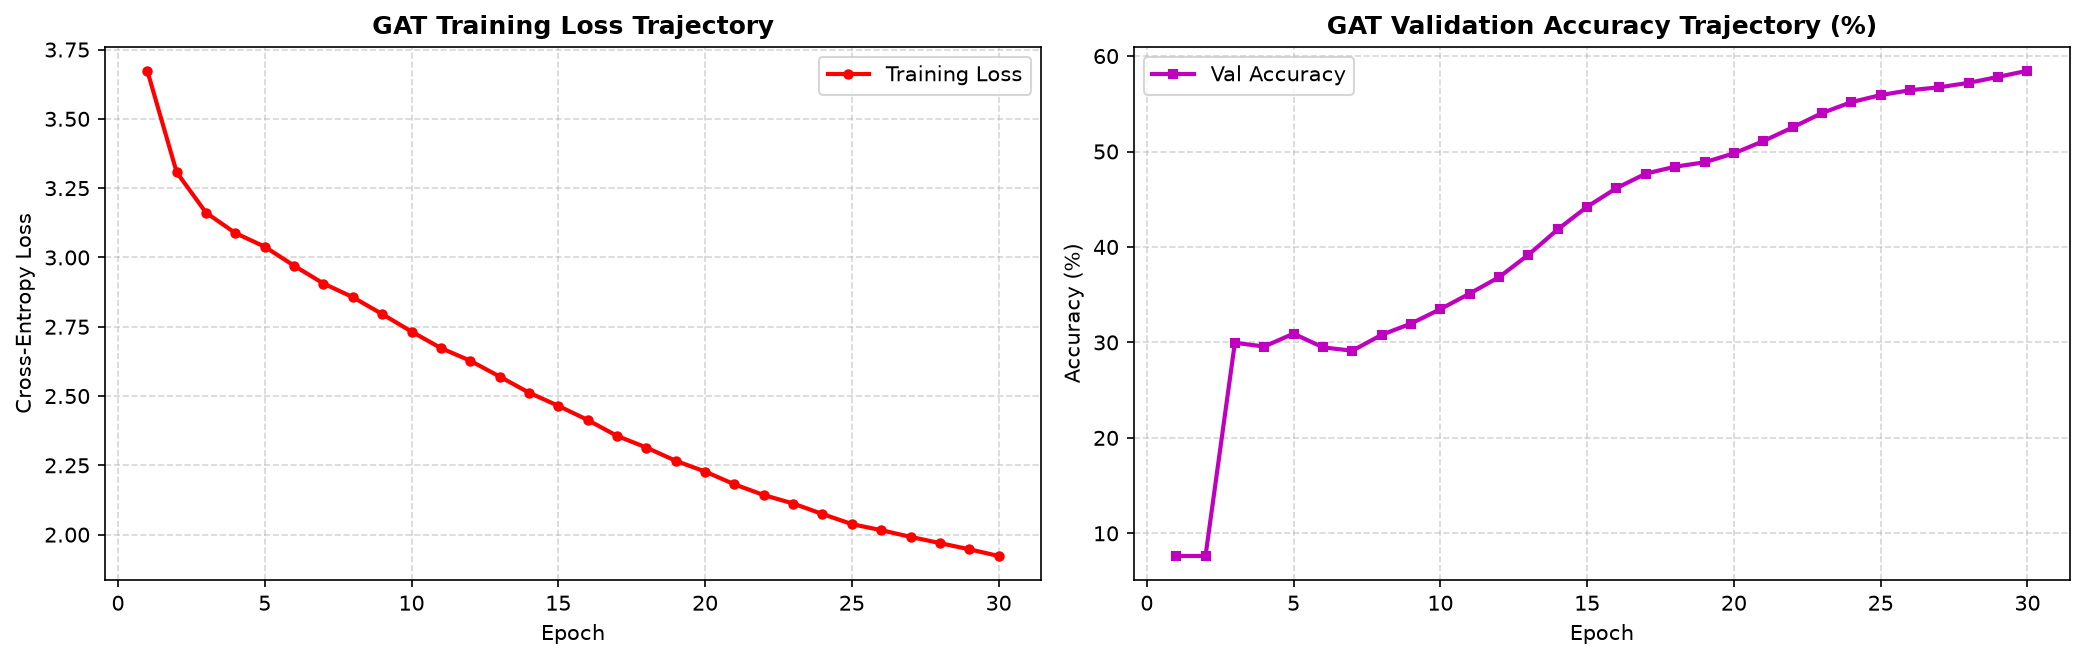

✅ Best GAT Validation Accuracy: 58.46%
✅ GAT Model Checkpoint saved to models/best_gat.pt


In [3]:
print("🚀 Starting GAT Model Training (30 Epochs)...")
history = fit(
    model=gat_model,
    data=data,
    split_idx=split_idx,
    epochs=30,
    learning_rate=0.005,
    checkpoint_path=MODELS_DIR / 'best_gat.pt'
)

results_dir = RESULTS_DIR / 'training'
results_dir.mkdir(parents=True, exist_ok=True)
history.to_csv(results_dir / 'gat_training_history.csv', index=False)

# Plot Training Loss & Validation Accuracy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5), dpi=150)

ax1.plot(history['epoch'], history['loss'], 'r-o', lw=2, markersize=4, label='Training Loss')
ax1.set_title('GAT Training Loss Trajectory', fontsize=12, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=10)
ax1.set_ylabel('Cross-Entropy Loss', fontsize=10)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend()

ax2.plot(history['epoch'], history['validation_accuracy'] * 100, 'm-s', lw=2, markersize=4, label='Val Accuracy')
ax2.set_title('GAT Validation Accuracy Trajectory (%)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epoch', fontsize=10)
ax2.set_ylabel('Accuracy (%)', fontsize=10)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend()

plt.tight_layout()
plt.savefig(results_dir / 'gat_training_plot.png', dpi=180, bbox_inches='tight')
plt.show()

print(f"✅ Best GAT Validation Accuracy: {history['validation_accuracy'].max() * 100:.2f}%")
print("✅ GAT Model Checkpoint saved to models/best_gat.pt")